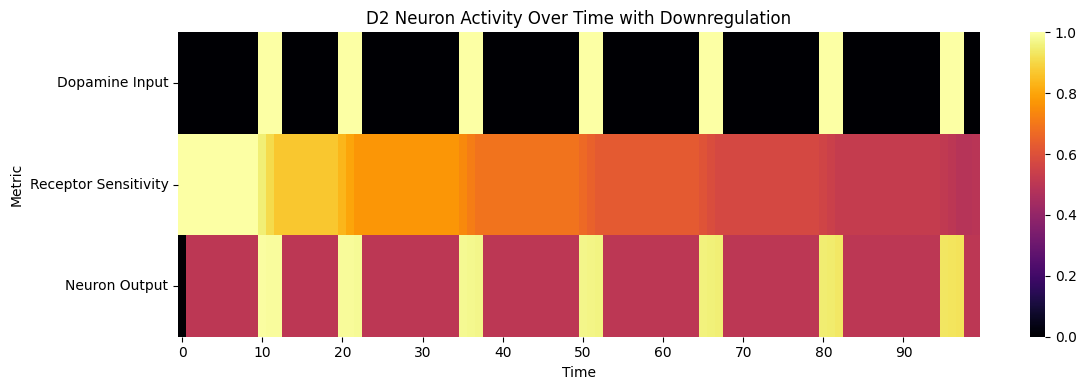

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Simulating parameters 
# Dopamine bursts 
timesteps = 100
dopamine_bursts = np.zeros(timesteps)

# Simulating dopamine bursts at specific time intervals 
burst_intervals = [10, 20, 35, 50, 65, 80, 95]
for i in burst_intervals:
    dopamine_bursts[i:i+3] = 1.0 

# Receptor sensativity coresponding to receptor density 
# Initial sensativity is homeostatic 

sensitivity = np.ones(timesteps)
decay_rate = 0.01 # How fast receptor downregulates per burst 
firing_output = np.zeros(timesteps)

# Sigmoind function 
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Neuron response 
exposure = 0
for t in range(1, timesteps):
    dopamine_input = dopamine_bursts[t]
    exposure += dopamine_input
    sensitivity[t] = 1 / (1 + 0.05 * exposure)
    firing_output[t] = sigmoid(5 * dopamine_input * sensitivity[t-1])

# Bursts decrease future sensativity when using substances the brain recieves large bursts of dopamine 
# These large bursts cause D2 Neurons to downregulate 
# It's a neuroplasticity defense mechanisum that prevents the circuits of overstimulation 
# Prevents the circuits from frying (cognitive overload) 

if dopamine_input > 0.8:
    sensitivity[t] = sensitivity[t-1] * np.exp(-0.05)
else:
    sensitivity[t] = min(1.0, sensitivity[t-1] + 0.005)


recovery_rate = 0.005
if dopamine_input > 0.8:
    sensitivity[t] = sensitivity[t-1] * np.exp(-0.05)
else:
    sensitivity[t] = min(1.0, sensitivity[t-1] + recovery_rate)

# Create a heatmap matrix: row = metric, col = time
data_matrix = np.vstack([dopamine_bursts, sensitivity, firing_output])
labels = ['Dopamine Input', 'Receptor Sensitivity', 'Neuron Output']

# Convert to DataFrame for better plotting
df = pd.DataFrame(data_matrix, index=labels)

# Create the heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(df, cmap='inferno', cbar=True, xticklabels=10, yticklabels=labels)
plt.title("D2 Neuron Activity Over Time with Downregulation")
plt.xlabel("Time")
plt.ylabel("Metric")
plt.tight_layout()
plt.show()
